# Description of Resume Screening Using ML and NLP

Resume screening using ML and NLP automates the process of evaluating resumes to identify candidates who best match a job description. This is particularly useful for recruiters dealing with large volumes of applications. The process leverages NLP to process and understand resume text and ML to classify or rank resumes based on relevance to specific job roles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import plotly.graph_objs as go
import os
import missingno as msno
import warnings
import sklearn
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from pandas.plotting import scatter_matrix
from sklearn import metrics
from wordcloud import WordCloud

In [2]:
# Load the dataset
try:
    df = pd.read_csv('/kaggle/input/resume-dataset/UpdatedResumeDataSet.csv', encoding='utf-8')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset not found. Please ensure 'UpdatedResumeDataSet.csv' is in the specified path.")
    exit() # Exit if the file isn't found

Dataset loaded successfully.


# Remove duplicate data

In [3]:
# Drop duplicates and NaNs
initial_rows = df.shape[0]
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
rows_after_cleaning = df.shape[0]
print(f"\nRemoved {initial_rows - rows_after_cleaning} duplicate and NaN rows.")
print(f"DataFrame now has {rows_after_cleaning} rows.")
 


Removed 796 duplicate and NaN rows.
DataFrame now has 166 rows.


In [4]:
# Display basic info and first few rows
print("\n--- Initial DataFrame Info ---")
df.info()
print("\n--- First 10 Rows of DataFrame ---")
print(df.head(10))


--- Initial DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 166 entries, 0 to 898
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  166 non-null    object
 1   Resume    166 non-null    object
dtypes: object(2)
memory usage: 3.9+ KB

--- First 10 Rows of DataFrame ---
       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...
5  Data Science  SKILLS C Basics, IOT, Python, MATLAB, Data Sci...
6  Data Science  Skills â¢ Python â¢ Tableau â¢ Data Visuali...
7  Data Science  Education Details \r\n B.Tech   Rayat and Bahr...
8  Data Science  Personal Skills â¢ A

In [5]:
 df.tail(5)

,Category,Resume
894,Testing,Computer Skills: â¢ Proficient in MS office (...
895,Testing,â Willingness to accept the challenges. â ...
896,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
897,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...
898,Testing,Skill Set OS Windows XP/7/8/8.1/10 Database MY...


In [6]:
print ("✔️Displaying the distinct categories of resume:\n\n ")
print (df['Category'].unique())

✔️Displaying the distinct categories of resume:

 
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [7]:
print(f'✔️The shape of the data is: {df.shape}\n')
print(f'✔️The size of the data is: {df.size}\n')

✔️The shape of the data is: (166, 2)

✔️The size of the data is: 332



In [8]:
df.dtypes

Category    object
Resume      object
dtype: object

In [9]:
df.index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       854, 855, 856, 892, 893, 894, 895, 896, 897, 898],
      dtype='int64', length=166)

In [10]:
df.columns

Index(['Category', 'Resume'], dtype='object')

In [11]:
df.columns.tolist()

['Category', 'Resume']

In [12]:
df.loc[4]

Category                                         Data Science
Resume      Education Details \r\n MCA   YMCAUST,  Faridab...
Name: 4, dtype: object

In [13]:
df.iloc[0]

Category                                         Data Science
Resume      Skills * Programming Languages: Python (pandas...
Name: 0, dtype: object

In [14]:
df.isna().sum()

Category    0
Resume      0
dtype: int64

In [15]:
print(df.ndim) 

2


In [16]:
if df.duplicated().any()>0:
    print(f"✔️The number of duplicates are {df.duplicated().sum()}")
else:
    print(f'✔️There are no duplicates r in the dataset')

✔️There are no duplicates r in the dataset


In [17]:
df.describe().T

,count,unique,top,freq
Category,166,25,Java Developer,13
Resume,166,166,Skill Set OS Windows XP/7/8/8.1/10 Database MY...,1


In [18]:
category = df['Category'].value_counts().reset_index()
category

,Category,count
0,Java Developer,13
1,Database,11
2,Advocate,10
3,HR,10
4,Data Science,10
5,Automation Testing,7
6,DevOps Engineer,7
7,Testing,7
8,DotNet Developer,7
9,Hadoop,7


Category
Java Developer               13
Database                     11
Advocate                     10
HR                           10
Data Science                 10
Automation Testing            7
DevOps Engineer               7
Testing                       7
DotNet Developer              7
Hadoop                        7
SAP Developer                 6
Python Developer              6
Health and fitness            6
Civil Engineer                6
Arts                          6
Business Analyst              6
Sales                         5
Blockchain                    5
Mechanical Engineer           5
ETL Developer                 5
Electrical Engineering        5
Network Security Engineer     5
Web Designing                 4
Operations Manager            4
PMO                           3
Name: count, dtype: int64


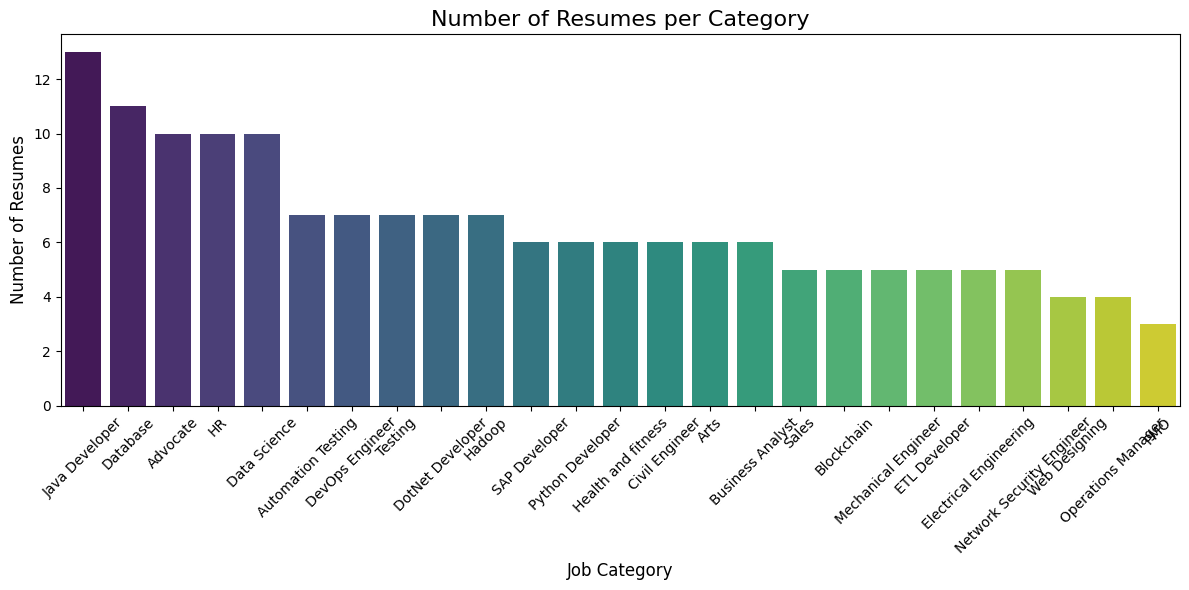

In [19]:
category = df['Category'].value_counts() 
print(category) 

plt.figure(figsize=(12, 6))
sns.barplot(x=category.index, y=category.values, palette="viridis")
plt.title("Number of Resumes per Category", fontsize=16)
plt.xlabel("Job Category", fontsize=12)
plt.ylabel("Number of Resumes", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

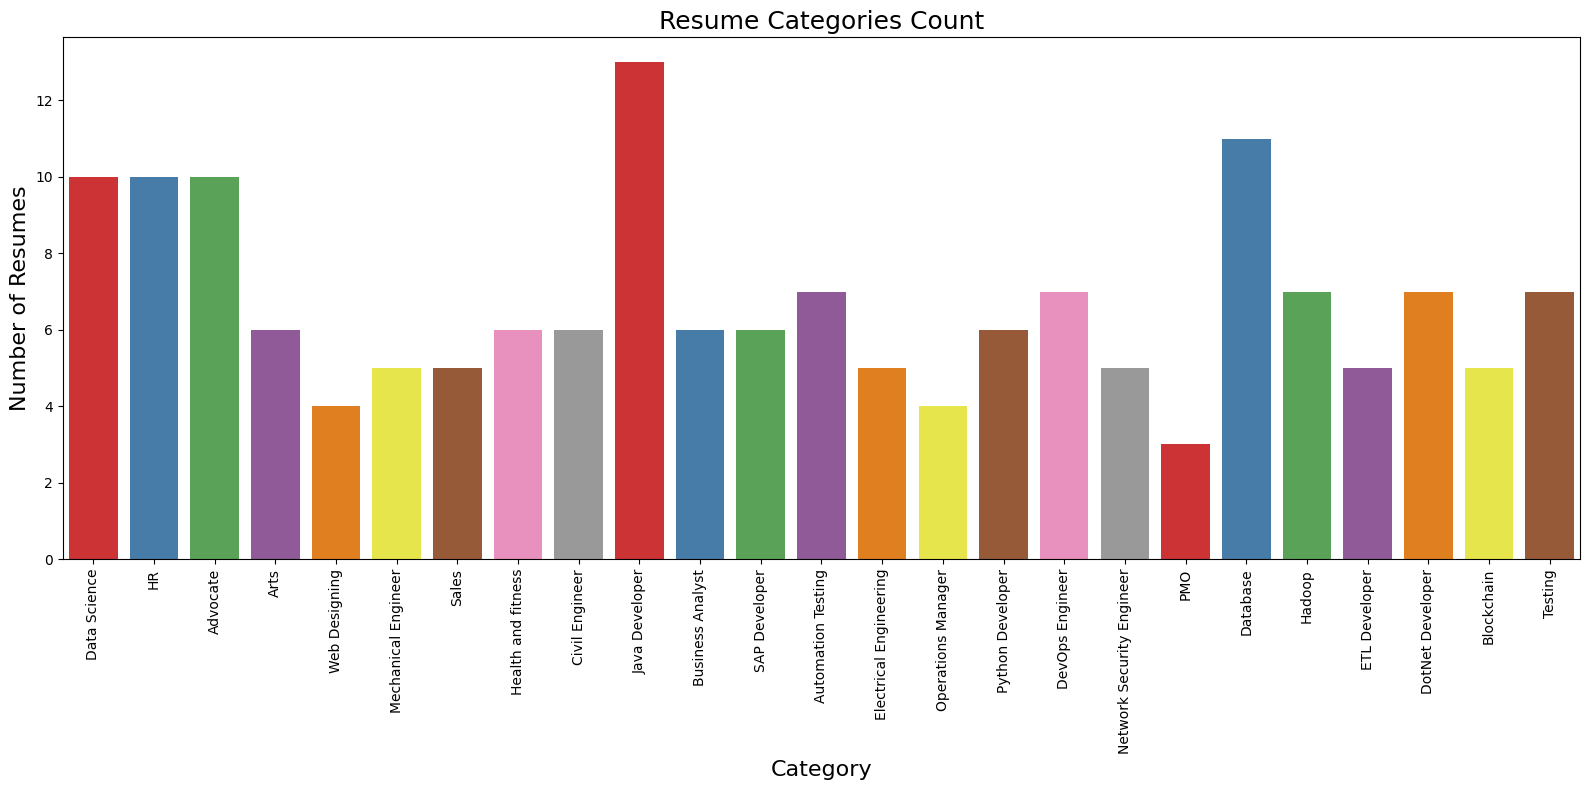

In [20]:
plt.figure(figsize=(16, 8))
sns.countplot(x='Category', data=df, palette='Set1')
plt.title("Resume Categories Count", fontsize=18)
plt.xlabel("Category", fontsize=16)
plt.ylabel("Number of Resumes", fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

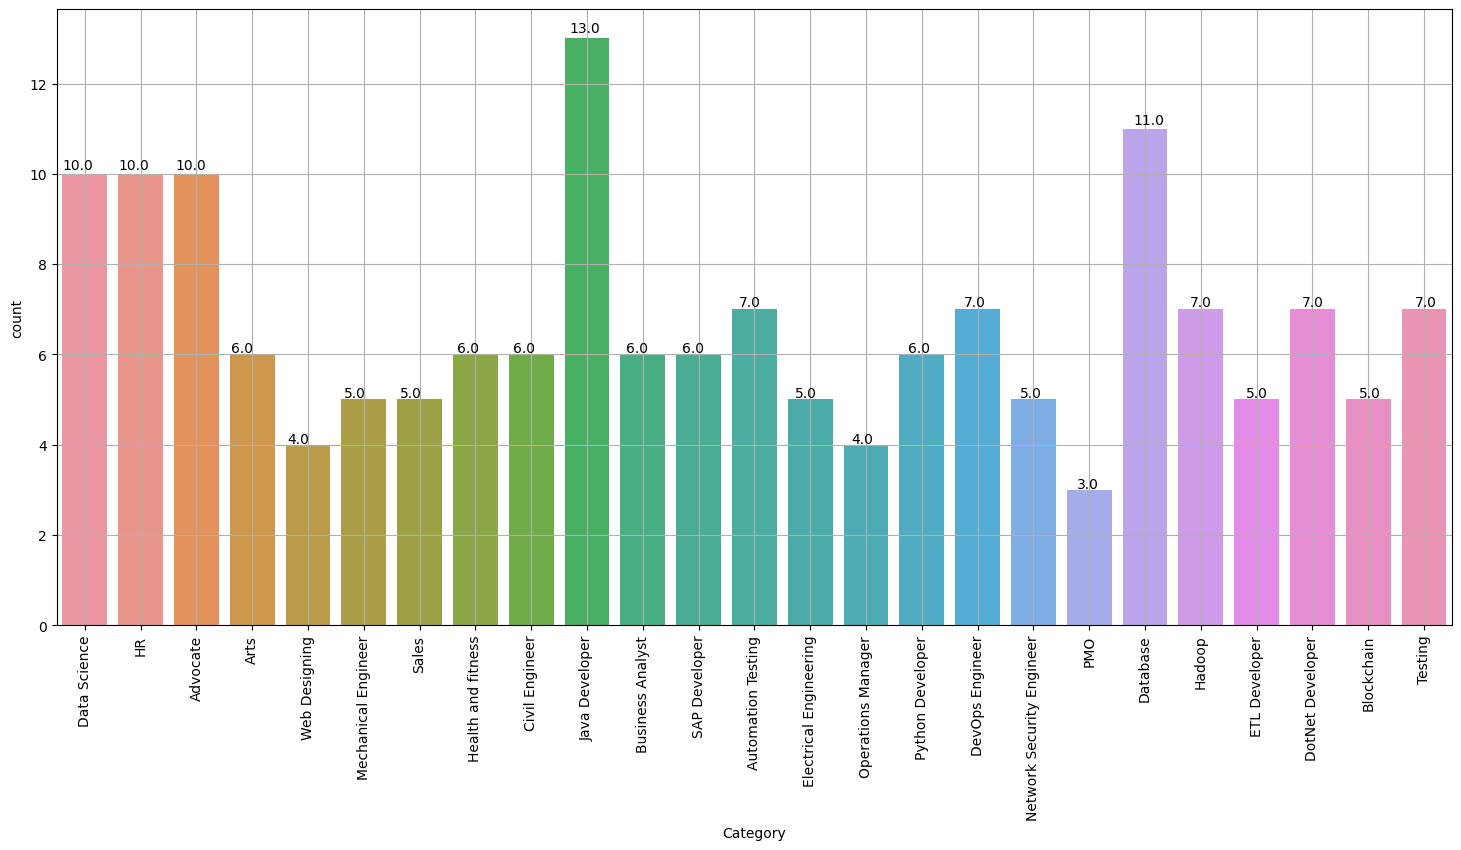

In [21]:
import seaborn as sns
plt.figure(figsize=(18,8))
plt.xticks(rotation=90)
ax=sns.countplot(x="Category", data=df)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
plt.grid()

In [22]:
reg=df['Category'].value_counts().reset_index()
reg

,Category,count
0,Java Developer,13
1,Database,11
2,Advocate,10
3,HR,10
4,Data Science,10
5,Automation Testing,7
6,DevOps Engineer,7
7,Testing,7
8,DotNet Developer,7
9,Hadoop,7


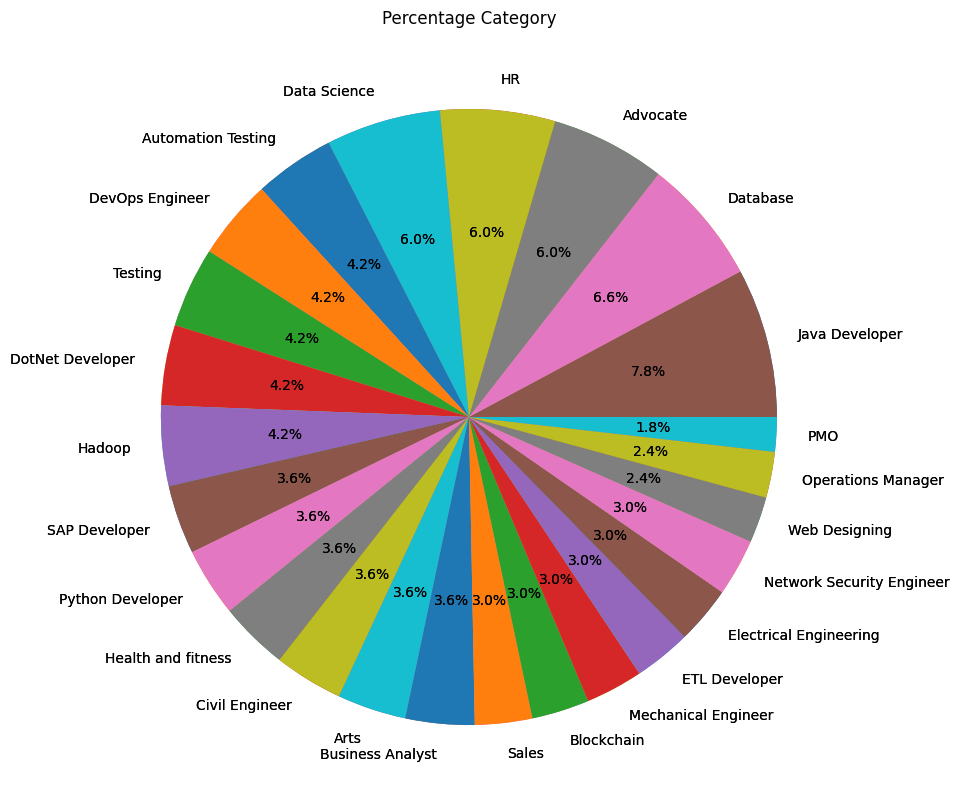

In [23]:
plt.figure(figsize = (16,10))
plt.pie(category.values, labels = category.index, autopct='%1.1f%%')
plt.title("Percentage Category")
plt.pie(category.values, labels = category.index, autopct='%1.1f%%') 
plt.show()

In [24]:
reg = df['Category'].unique()
print("✔️Unique Resume Categories:")
print(reg)

✔️Unique Resume Categories:
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [25]:
print("✔️Number of Unique Categories:", len(reg))
print("Categories:")
for idx, cat in enumerate(reg, 1):
    print(f"{idx}. {cat}")

✔️Number of Unique Categories: 25
Categories:
1. Data Science
2. HR
3. Advocate
4. Arts
5. Web Designing
6. Mechanical Engineer
7. Sales
8. Health and fitness
9. Civil Engineer
10. Java Developer
11. Business Analyst
12. SAP Developer
13. Automation Testing
14. Electrical Engineering
15. Operations Manager
16. Python Developer
17. DevOps Engineer
18. Network Security Engineer
19. PMO
20. Database
21. Hadoop
22. ETL Developer
23. DotNet Developer
24. Blockchain
25. Testing


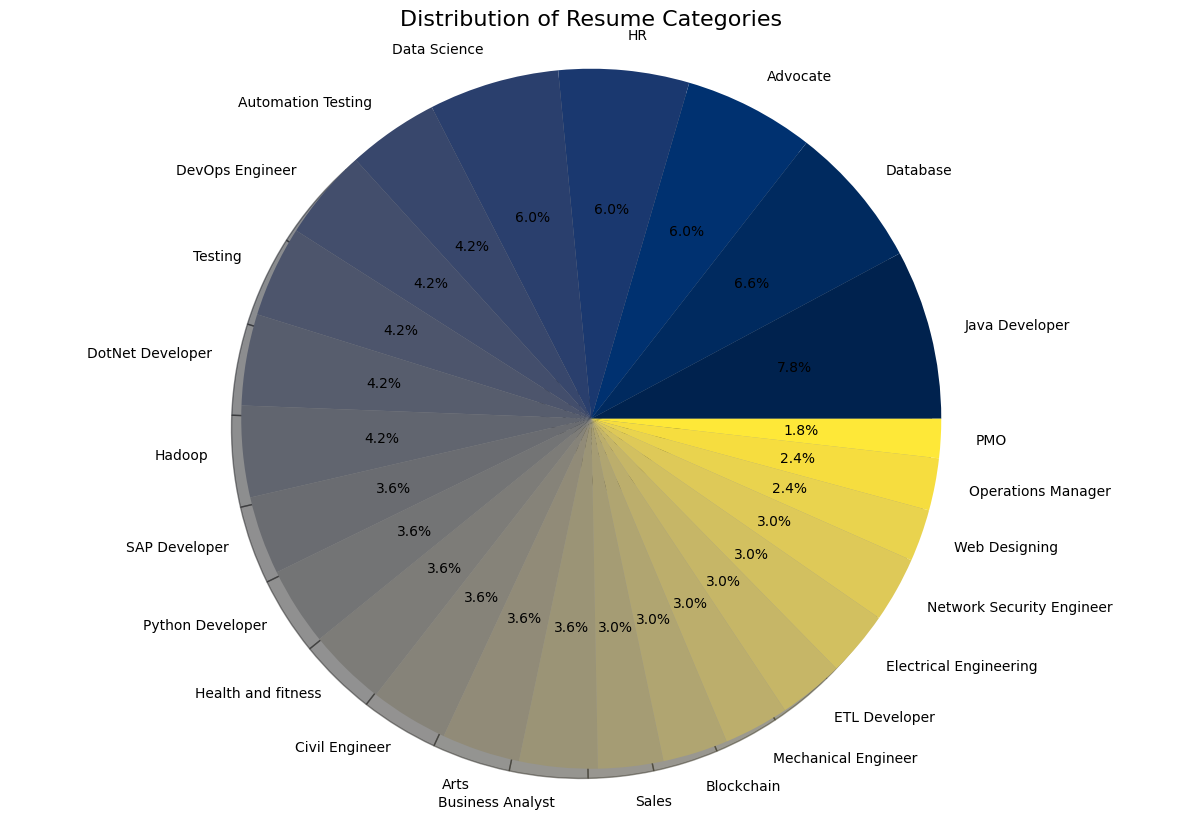

In [26]:
reg_1 = df['Category'].value_counts()
labels = reg_1.index
plt.figure(figsize=(15, 10))
plt.pie(reg_1, labels=labels, autopct='%1.1f%%', shadow=True,
        colors=plt.cm.cividis(np.linspace(0, 1, len(labels))))  # dynamically adjust colors

plt.title("Distribution of Resume Categories", fontsize=16)
plt.axis('equal')  # Makes the pie chart a perfect circle
plt.show()

In [27]:
print("✅ Category:", df['Category'][0])
print("\n✔️Resume Preview:\n")
print(df['Resume'][0][:1000])

✅ Category: Data Science

✔️Resume Preview:

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Frau

In [28]:
resume_text = df['Resume'][0]
print(resume_text[:600]) 

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask


# Data Cleaning

In [29]:
import re
def clean_resume(text):
    """
    Cleans the resume text by removing URLs, RT/cc, hashtags, mentions,
    special characters, non-ASCII characters, and extra spaces.
    """
    text = re.sub('http\\S+\\s*', ' ', text)  # Remove URLs
    text = re.sub('RT|cc', ' ', text)         # Remove RT and cc
    text = re.sub('#\\S+', '', text)          # Remove hashtags
    text = re.sub('@\\S+', ' ', text)         # Remove mentions
    # Remove punctuation
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"""), ' ', text)
    text = re.sub(r'[^\x00-\x7f]', r' ', text) # Remove non-ASCII characters
    text = re.sub('\s+', ' ', text)           # Remove extra spaces
    return text.strip()

# Apply the cleaning function to the 'Resume' column
# It's redundant to have both 'cleaned_resume' and 'Processed_Resume' doing the same thing.
# We'll stick with 'cleaned_resume' for consistency and clarity.
df['cleaned_resume'] = df['Resume'].apply(clean_resume)
print("\n--- ✅ DataFrame After Cleaning Resumes ---")
print(df.head())
 


--- ✅ DataFrame After Cleaning Resumes ---
       Category                                             Resume  \
0  Data Science  Skills * Programming Languages: Python (pandas...   
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...   
2  Data Science  Areas of Interest Deep Learning, Control Syste...   
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...   
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...   

                                      cleaned_resume  
0  Skills Programming Languages Python pandas num...  
1  Education Details May 2013 to May 2017 B E UIT...  
2  Areas of Interest Deep Learning Control System...  
3  Skills R Python SAP HANA Tableau SAP HANA SQL ...  
4  Education Details MCA YMCAUST Faridabad Haryan...  


## Testing the above custom function to remove certain details from Resume

In [30]:
clean_resume(" https://www.github.com Software Engineer with 3 years of experience in Data Structures and Algorithms Agile Scrum, SDLC, C++, Java MVC, JavaScript, Web Development, Python " +
           "Data Science, Machine Learning / AI, and Mainframe technologies Programming Languages: 	C/C++, Java, Python, SQL, JCL, Cobol, DB2" + 
           "Frameworks: %#####	Java Spring, Spring boot, React, Angular, NodeJs" +
           "Tools: 	GIT, Visual Studio Code, Sublime, Spyder, Jupyter Notebook, Bluezone, Netbeans, Jira, Confluence, Kanban, CI/CD (Jenkins, GitLab, Azure-Devops), AWS," + 
           "Data-Bricks Libraries: 	NumPy, Pandas, Matplotlib, nltk, Scikit learn, TensorFlow, Keras Other: 	Problem-Solving, Quick Learner, Time-Management")

'Software Engineer with 3 years of experience in Data Structures and Algorithms Agile Scrum SDLC C Java MVC JavaScript Web Development Python Data Science Machine Learning AI and Mainframe technologies Programming Languages C C Java Python SQL JCL Cobol DB2Frameworks Java Spring Spring boot React Angular NodeJsTools GIT Visual Studio Code Sublime Spyder Jupyter Notebook Bluezone Netbeans Jira Confluence Kanban CI CD Jenkins GitLab Azure Devops AWS Data Bricks Libraries NumPy Pandas Matplotlib nltk Scikit learn TensorFlow Keras Other Problem Solving Quick Learner Time Management'

>Applying above created Custom Function to process the data and creating new column "Processed_Resume"

In [31]:
df['Processed_Resume'] = df['Resume'].apply(lambda x: clean_resume(x))
df.head()

,Category,Resume,cleaned_resume,Processed_Resume
0,Data Science,Skills * Programming Languages: Python (pandas...,Skills Programming Languages Python pandas num...,Skills Programming Languages Python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,Education Details May 2013 to May 2017 B E UIT...,Education Details May 2013 to May 2017 B E UIT...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",Areas of Interest Deep Learning Control System...,Areas of Interest Deep Learning Control System...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,Skills R Python SAP HANA Tableau SAP HANA SQL ...,Skills R Python SAP HANA Tableau SAP HANA SQL ...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",Education Details MCA YMCAUST Faridabad Haryan...,Education Details MCA YMCAUST Faridabad Haryan...


## Clean all resumes in the dataset

In [32]:
# Clean all resumes in the dataset
df['Resume'] = df['Resume'].apply(clean_resume)

# Check cleaned version of first resume
print(df['Resume'][0])

Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in a elerating the r

# 📊 Resume Length Analysis by Category

In [33]:
# Calculate resume length (number of words)
df['resume_length'] = df['cleaned_resume'].apply(lambda x: len(x.split()))
print("\n--- ✅ DataFrame with Resume Length ---")
print(df.head())


--- ✅ DataFrame with Resume Length ---
       Category                                             Resume  \
0  Data Science  Skills Programming Languages Python pandas num...   
1  Data Science  Education Details May 2013 to May 2017 B E UIT...   
2  Data Science  Areas of Interest Deep Learning Control System...   
3  Data Science  Skills R Python SAP HANA Tableau SAP HANA SQL ...   
4  Data Science  Education Details MCA YMCAUST Faridabad Haryan...   

                                      cleaned_resume  \
0  Skills Programming Languages Python pandas num...   
1  Education Details May 2013 to May 2017 B E UIT...   
2  Areas of Interest Deep Learning Control System...   
3  Skills R Python SAP HANA Tableau SAP HANA SQL ...   
4  Education Details MCA YMCAUST Faridabad Haryan...   

                                    Processed_Resume  resume_length  
0  Skills Programming Languages Python pandas num...            653  
1  Education Details May 2013 to May 2017 B E UIT...          

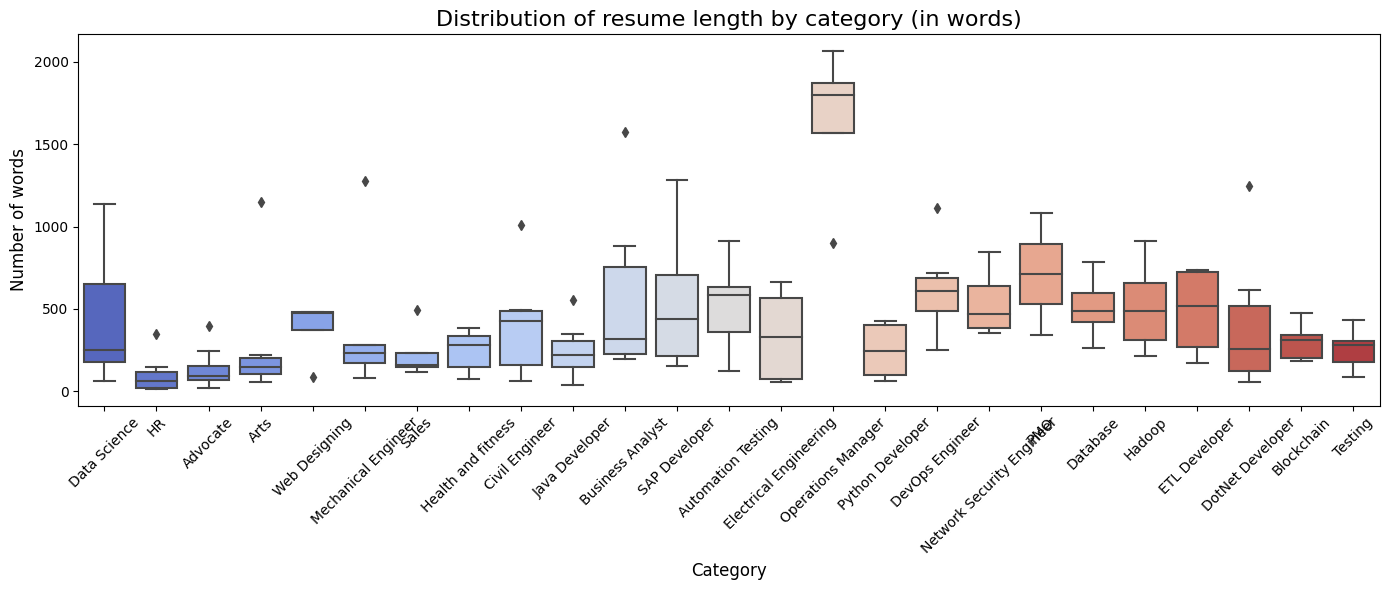

In [34]:
# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Category', y='resume_length', palette='coolwarm')
plt.title("Distribution of resume length by category (in words)", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Number of words", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

>Encoding the Category column 

In [35]:
# Encode the 'Category' column into numerical labels
label_encoder = LabelEncoder()
df['Encoded_Category'] = label_encoder.fit_transform(df['Category'])


In [36]:
# Display the mapping of original categories to encoded labels
category_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\n--- ✅ Category Encoding Mapping ---")
print(category_mapping)

print("\n--- ✅ DataFrame After Category Encoding ---")
print(df.head())


--- ✅ Category Encoding Mapping ---
{'Advocate': 0, 'Arts': 1, 'Automation Testing': 2, 'Blockchain': 3, 'Business Analyst': 4, 'Civil Engineer': 5, 'Data Science': 6, 'Database': 7, 'DevOps Engineer': 8, 'DotNet Developer': 9, 'ETL Developer': 10, 'Electrical Engineering': 11, 'HR': 12, 'Hadoop': 13, 'Health and fitness': 14, 'Java Developer': 15, 'Mechanical Engineer': 16, 'Network Security Engineer': 17, 'Operations Manager': 18, 'PMO': 19, 'Python Developer': 20, 'SAP Developer': 21, 'Sales': 22, 'Testing': 23, 'Web Designing': 24}

--- ✅ DataFrame After Category Encoding ---
       Category                                             Resume  \
0  Data Science  Skills Programming Languages Python pandas num...   
1  Data Science  Education Details May 2013 to May 2017 B E UIT...   
2  Data Science  Areas of Interest Deep Learning Control System...   
3  Data Science  Skills R Python SAP HANA Tableau SAP HANA SQL ...   
4  Data Science  Education Details MCA YMCAUST Faridabad Harya

## Exploratory Data Analysis (EDA)

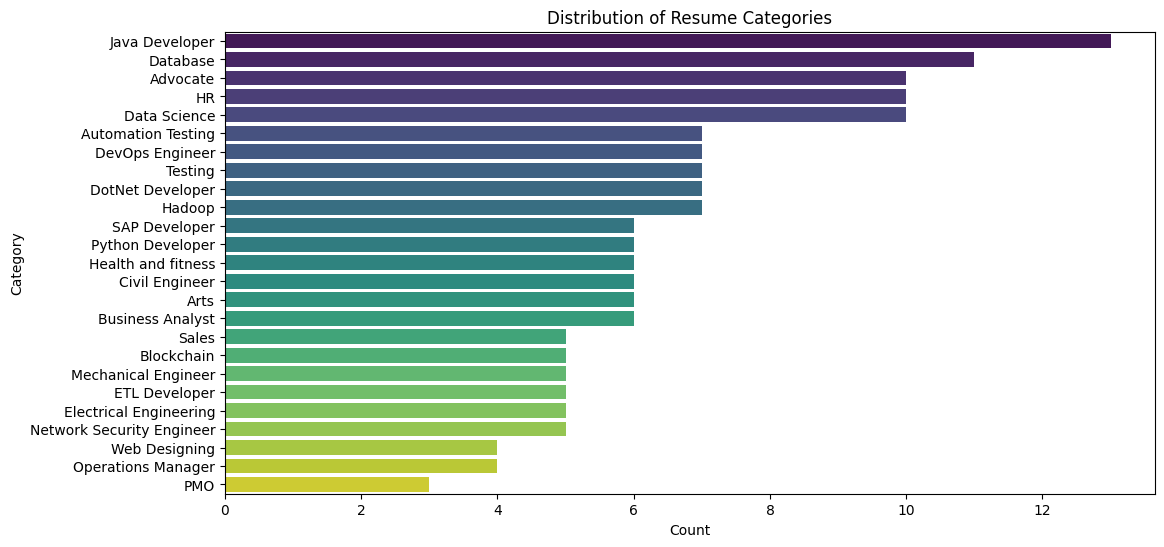

In [37]:
# Distribution of Categories
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Category', order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribution of Resume Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

# 🧾 Word frequency analysis by category

In [38]:
from collections import Counter
# List of stop words (can be replaced with nltk.corpus.stopwords)
stopwords = set([
    'and', 'the', 'to', 'a', 'in', 'for', 'of', 'on', 'with', 'as', 'is', 'i',
    'this', 'that', 'have', 'it', 'an', 'by', 'at', 'from', 'am', 'be'
])

# Categories for analysis
target_categories = ['Data Science', 'HR', 'Testing', 'Web Designing']

# For each category - find the top 10 words
for category in target_categories:
    texts = df[df['Category'] == category]['cleaned_resume']
    all_words = ' '.join(texts).split()
    filtered_words = [word for word in all_words if word not in stopwords and len(word) > 2]
    most_common = Counter(filtered_words).most_common(10)

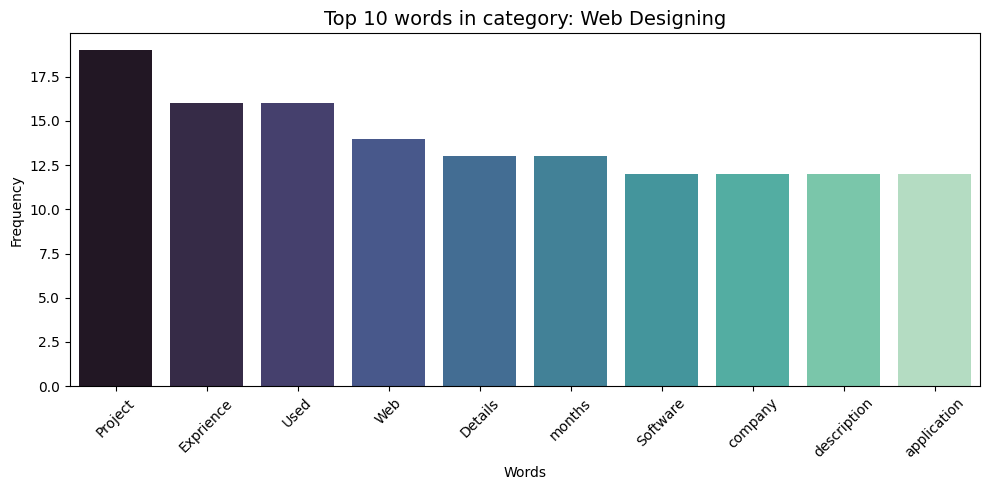

In [39]:
import seaborn as sns
# Visualization
words, counts = zip(*most_common)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(words), y=list(counts), palette='mako')
plt.title(f"Top 10 words in category: {category}", fontsize=14)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vectorization (TF-IDF)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer to ignore common English stopwords
tfidf = TfidfVectorizer(stop_words='english')

# Learn vocabulary and idf from resumes
tfidf.fit(df['Resume'])

# Transform all resumes into TF-IDF feature matrix (sparse matrix)
X = tfidf.transform(df['Resume'])

print(f"✅ TF-IDF matrix shape: {X.shape}")

✅ TF-IDF matrix shape: (166, 7351)


In [41]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df['cleaned_resume'])

>Label encoding

In [42]:
le = LabelEncoder()
y = le.fit_transform(df['Category'])

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df['Processed_Resume'])
requiredText  = tfidf.transform(df['Processed_Resume'])
print(requiredText)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27126 stored elements and shape (166, 7351)>
  Coords	Values
  (0, 7337)	0.0729806495591119
  (0, 7325)	0.01522988731314418
  (0, 7272)	0.016709728809701594
  (0, 7268)	0.07741779201292691
  (0, 7267)	0.041835796527921874
  (0, 7266)	0.07739814384847232
  (0, 7124)	0.08367159305584375
  (0, 7111)	0.0347694672433303
  (0, 7042)	0.03649032477955595
  (0, 7038)	0.07741779201292691
  (0, 7025)	0.0161382166076951
  (0, 7001)	0.041835796527921874
  (0, 6975)	0.014988871273475937
  (0, 6971)	0.05800284745766545
  (0, 6969)	0.01998637938752269
  (0, 6964)	0.030236523736639116
  (0, 6935)	0.038708896006463454
  (0, 6910)	0.02370225958296852
  (0, 6909)	0.026297094973505953
  (0, 6827)	0.041835796527921874
  (0, 6806)	0.041835796527921874
  (0, 6722)	0.18245162389777977
  (0, 6721)	0.06567471887379542
  (0, 6720)	0.08822080223227005
  (0, 6681)	0.036350646661748
  :	:
  (165, 1599)	0.049247582469583766
  (165, 1408)	0.0141559303290084

## Split into train/test

In [44]:
# Split data into training and testing sets for text vectorization
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_resume'], df['Encoded_Category'], test_size=0.2, random_state=42, stratify=df['Encoded_Category']
)

In [45]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000) # Limiting features for efficiency

In [46]:
# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

In [47]:
# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

In [48]:
print(f"\nTF-IDF Vectorization complete:")
print(f"✅ Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"✅ Shape of X_test_tfidf: {X_test_tfidf.shape}")


TF-IDF Vectorization complete:
✅ Shape of X_train_tfidf: (132, 5000)
✅ Shape of X_test_tfidf: (34, 5000)


In [49]:
# Find the minimum class size in the training set
min_class_size = min(np.bincount(y_train))
print("✅ Minimum class size:", min_class_size)

✅ Minimum class size: 2


In [50]:
le.classes_

array(['Advocate', 'Arts', 'Automation Testing', 'Blockchain',
       'Business Analyst', 'Civil Engineer', 'Data Science', 'Database',
       'DevOps Engineer', 'DotNet Developer', 'ETL Developer',
       'Electrical Engineering', 'HR', 'Hadoop', 'Health and fitness',
       'Java Developer', 'Mechanical Engineer',
       'Network Security Engineer', 'Operations Manager', 'PMO',
       'Python Developer', 'SAP Developer', 'Sales', 'Testing',
       'Web Designing'], dtype=object)

**Here ‘Advocate’ is class 0, ‘Arts’ is class 1, and so on…**

# Model Training and Evaluation (Basic Example)

In [51]:

# Using Multinomial Naive Bayes as a baseline model
# OneVsRestClassifier is suitable for multi-label classification,
# but here it wraps a multi-class classifier (MultinomialNB) for consistent API if needed later.
nb_classifier = OneVsRestClassifier(MultinomialNB())
nb_classifier.fit(X_train_tfidf, y_train)

OneVsRestClassifier(estimator=MultinomialNB())

## Model evaluation

In [52]:
# Make predictions on the test set
y_pred_nb = nb_classifier.predict(X_test_tfidf)


In [53]:
# Evaluate the model
print("\n--- ✅ Multinomial Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))
 


--- ✅ Multinomial Naive Bayes Classification Report ---
                           precision    recall  f1-score   support

                 Advocate       0.67      1.00      0.80         2
                     Arts       0.00      0.00      0.00         1
       Automation Testing       0.50      1.00      0.67         1
               Blockchain       0.00      0.00      0.00         1
         Business Analyst       0.00      0.00      0.00         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       0.67      1.00      0.80         2
                 Database       0.40      1.00      0.57         2
          DevOps Engineer       0.00      0.00      0.00         1
         DotNet Developer       0.00      0.00      0.00         2
            ETL Developer       0.00      0.00      0.00         1
   Electrical Engineering       1.00      1.00      1.00         1
                       HR       1.00      1.00      1.00         2
    

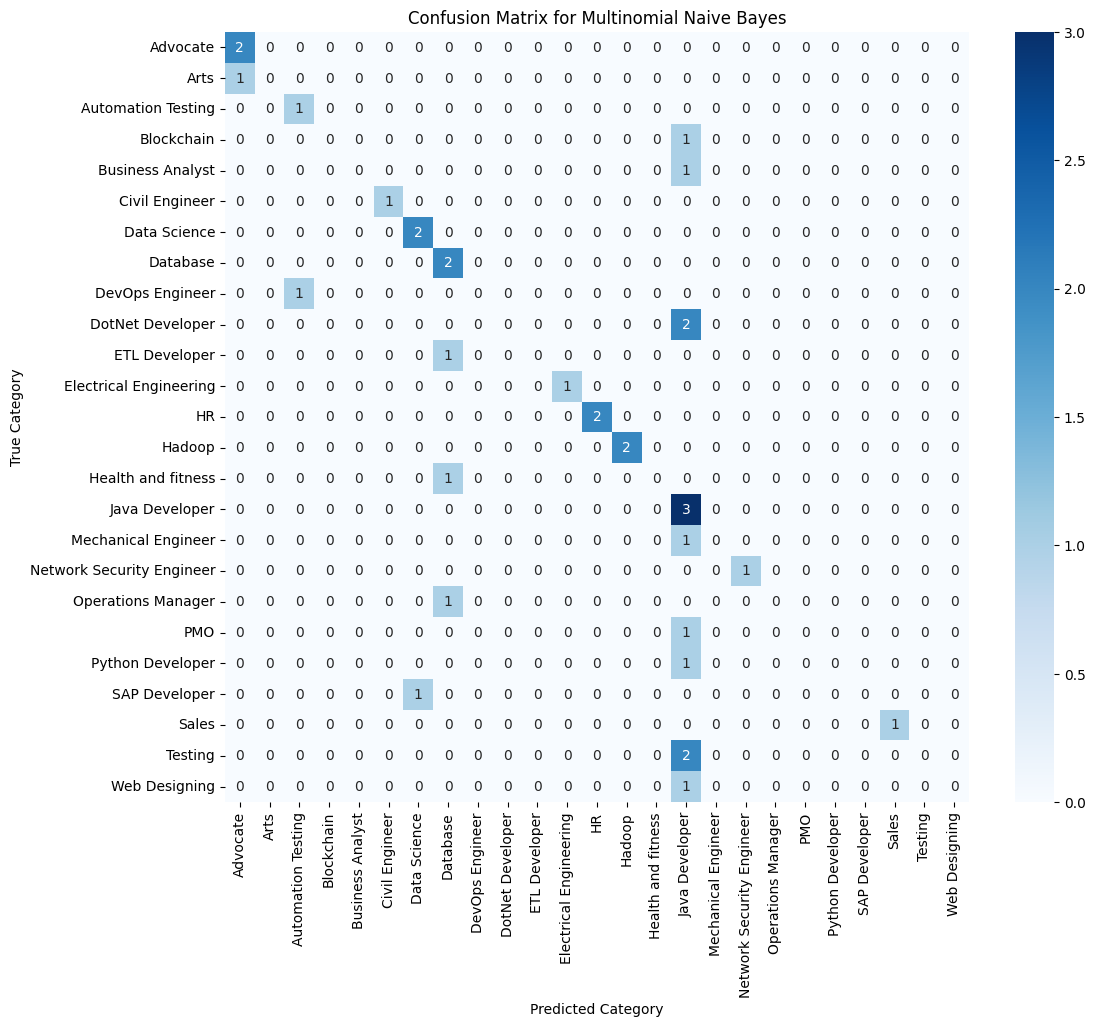

In [54]:
# Confusion Matrix for MNB
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.title('Confusion Matrix for Multinomial Naive Bayes')
plt.show()

In [55]:
print(f"\n✅ Accuracy Score (Multinomial Naive Bayes): {accuracy_score(y_test, y_pred_nb):.4f}")
 


✅ Accuracy Score (Multinomial Naive Bayes): 0.5294


In [56]:
# Encode the target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Category'])

print("\n--- ✅ TF-IDF Feature Shape ---")
print(X.shape)


--- ✅ TF-IDF Feature Shape ---
(166, 5000)


In [57]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n--- Data Split Information ---")
print(f"✅ Shape of X_train: {X_train.shape}")
print(f"✅ Shape of X_test: {X_test.shape}")
print(f"✅ Shape of y_train: {y_train.shape}")
print(f"✅ Shape of y_test: {y_test.shape}")
 


--- Data Split Information ---
✅ Shape of X_train: (132, 5000)
✅ Shape of X_test: (34, 5000)
✅ Shape of y_train: (132,)
✅ Shape of y_test: (34,)



--- Training and Evaluating Multinomial Naive Bayes Model ---
✅ Multinomial Naive Bayes Accuracy: 0.4118

✅ Classification Report (Multinomial Naive Bayes):
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         2
                     Arts       0.00      0.00      0.00         1
       Automation Testing       0.00      0.00      0.00         1
               Blockchain       0.00      0.00      0.00         1
         Business Analyst       0.00      0.00      0.00         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       0.67      1.00      0.80         2
                 Database       0.50      1.00      0.67         2
          DevOps Engineer       0.00      0.00      0.00         1
         DotNet Developer       0.00      0.00      0.00         2
            ETL Developer       0.00      0.00      0.00         1
   Electrical Engineering       0.00 

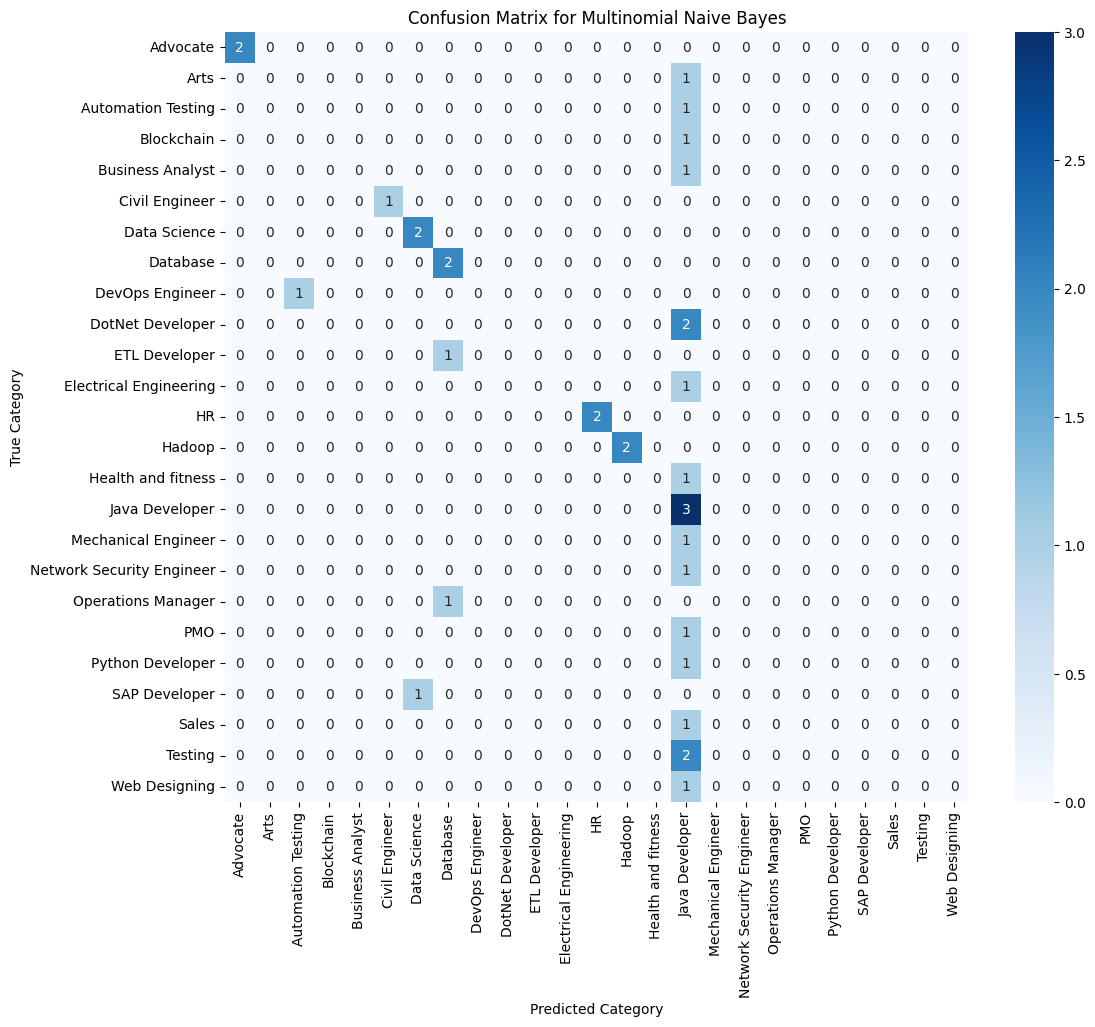

In [58]:
# --- Model 1: Multinomial Naive Bayes ---
print("\n--- Training and Evaluating Multinomial Naive Bayes Model ---")
mnb_classifier = MultinomialNB()
mnb_classifier.fit(X_train, y_train)
y_pred_mnb = mnb_classifier.predict(X_test)
print(f"✅ Multinomial Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_mnb):.4f}")
print("\n✅ Classification Report (Multinomial Naive Bayes):")
print(classification_report(y_test, y_pred_mnb, target_names=le.classes_))

# Confusion Matrix for MNB
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred_mnb), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.title('Confusion Matrix for Multinomial Naive Bayes')
plt.show()



--- Training and Evaluating Linear SVC Model ---
✅ Linear SVC Accuracy: 0.8529

✅ Classification Report (Linear SVC):
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         2
                     Arts       1.00      1.00      1.00         1
       Automation Testing       0.33      1.00      0.50         1
               Blockchain       1.00      1.00      1.00         1
         Business Analyst       0.50      1.00      0.67         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       1.00      1.00      1.00         2
                 Database       1.00      1.00      1.00         2
          DevOps Engineer       0.00      0.00      0.00         1
         DotNet Developer       1.00      1.00      1.00         2
            ETL Developer       1.00      1.00      1.00         1
   Electrical Engineering       1.00      1.00      1.00         1
         

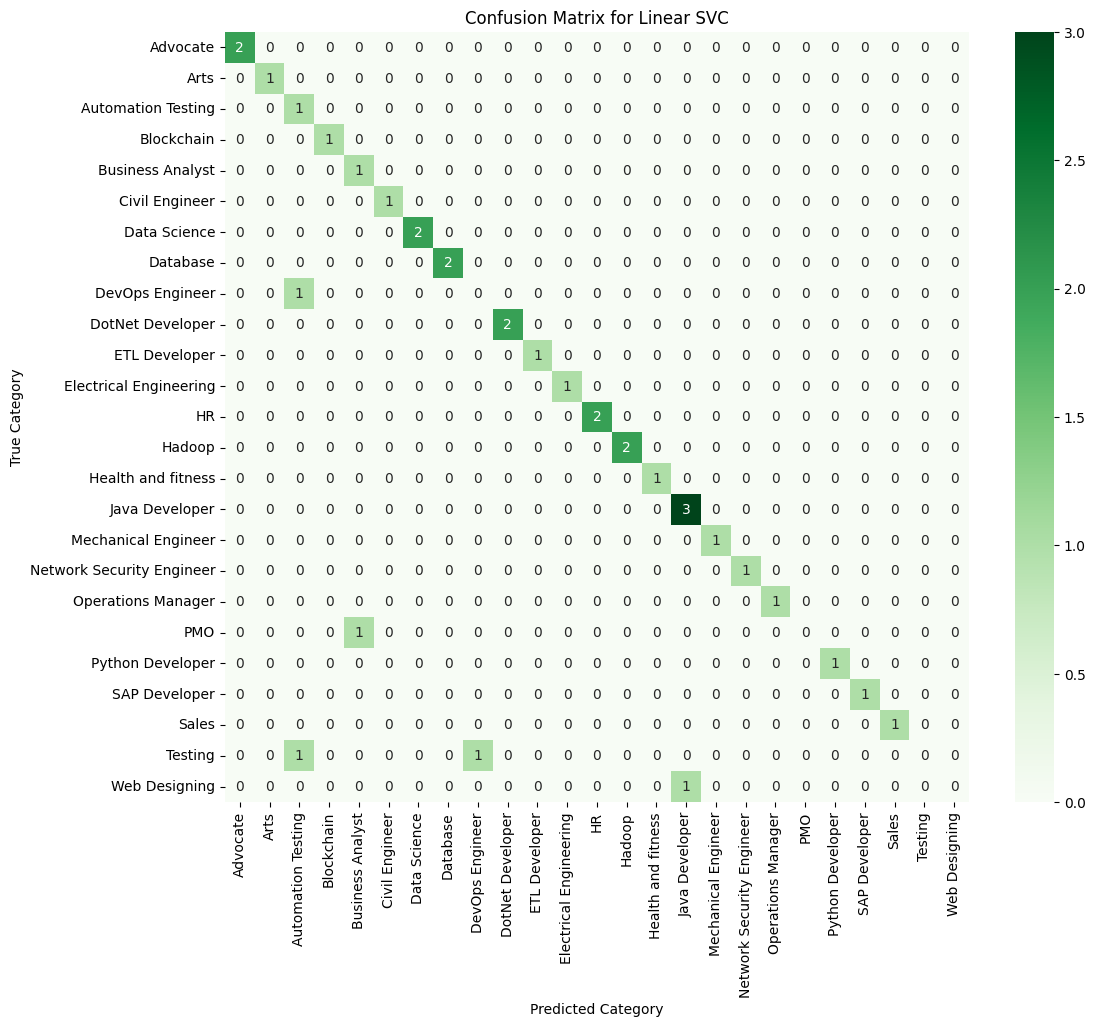

In [59]:
# --- Model 2: Support Vector Machine (Linear SVC) ---
# SVMs are often very effective for text classification
from sklearn.svm import LinearSVC

print("\n--- Training and Evaluating Linear SVC Model ---")
svc_classifier = LinearSVC(random_state=42)
svc_classifier.fit(X_train, y_train)
y_pred_svc = svc_classifier.predict(X_test)

print(f"✅ Linear SVC Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print("\n✅ Classification Report (Linear SVC):")
print(classification_report(y_test, y_pred_svc, target_names=le.classes_))

# Confusion Matrix for SVC
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.title('Confusion Matrix for Linear SVC')
plt.show()

In [60]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
rf_y_pred = rf_model.predict(X_test)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n--- Random Forest Model Evaluation ---")
print("✅ Accuracy:", accuracy_score(y_test, rf_y_pred))
 
 



--- Random Forest Model Evaluation ---
✅ Accuracy: 0.6470588235294118


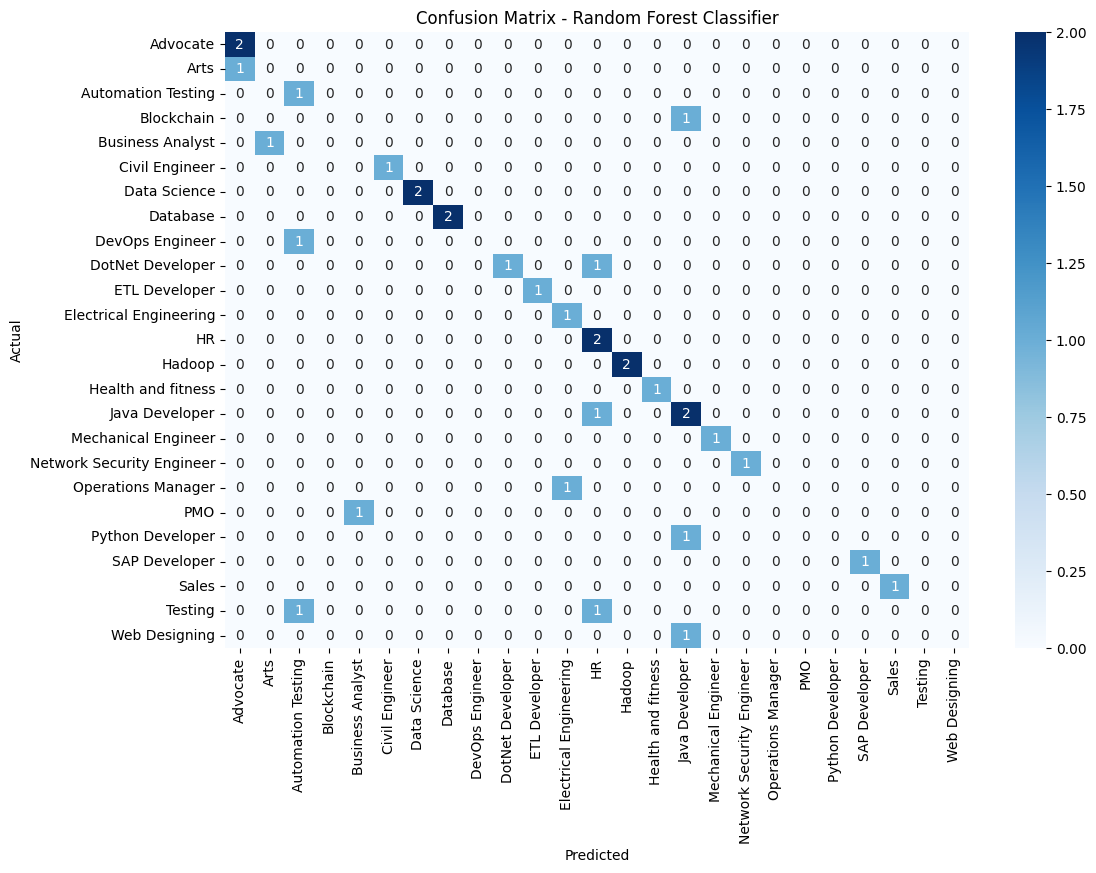

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the confusion matrix
conf_mat = confusion_matrix(y_test, rf_y_pred)

# Plot the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

# Integrating Additional Features (e.g., resume_length)

In [62]:
# This demonstrates how you might combine text features with numerical features.
# You'd need to scale numerical features if they have vastly different ranges.

# Extract resume_length for train/test sets
# Ensure 'resume_length' is aligned with your train/test split.
# A more robust way is to include 'resume_length' in the initial split if it's a feature.
# For simplicity here, we'll align it based on the same indices.
X_train_length = df.loc[X_train_text.index, 'resume_length'].values.reshape(-1, 1)
X_test_length = df.loc[X_test_text.index, 'resume_length'].values.reshape(-1, 1)


In [63]:
# Horizontally stack TF-IDF features with resume length
X_train_combined = hstack([X_train_tfidf, X_train_length])
X_test_combined = hstack([X_test_tfidf, X_test_length])

print(f"\n✅ Shape of combined X_train (TF-IDF + resume_length): {X_train_combined.shape}")
print(f"✅ Shape of combined X_test (TF-IDF + resume_length): {X_test_combined.shape}")


✅ Shape of combined X_train (TF-IDF + resume_length): (132, 5001)
✅ Shape of combined X_test (TF-IDF + resume_length): (34, 5001)


In [64]:

# Train another model with combined features (e.g., K-Nearest Neighbors)
knn_classifier = KNeighborsClassifier(n_neighbors=5) # Example: Using 5 neighbors
knn_classifier.fit(X_train_combined, y_train)
y_pred_knn = knn_classifier.predict(X_test_combined)

print("\n---✅ K-Nearest Neighbors Classification Report (with combined features) ---")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))
print(f"\n✅ Accuracy Score (K-Nearest Neighbors - combined features): {accuracy_score(y_test, y_pred_knn):.4f}")


---✅ K-Nearest Neighbors Classification Report (with combined features) ---
                           precision    recall  f1-score   support

                 Advocate       0.00      0.00      0.00         2
                     Arts       0.00      0.00      0.00         1
       Automation Testing       0.00      0.00      0.00         1
               Blockchain       0.00      0.00      0.00         1
         Business Analyst       0.00      0.00      0.00         1
           Civil Engineer       0.00      0.00      0.00         1
             Data Science       0.00      0.00      0.00         2
                 Database       0.33      0.50      0.40         2
          DevOps Engineer       0.00      0.00      0.00         1
         DotNet Developer       0.00      0.00      0.00         2
            ETL Developer       0.00      0.00      0.00         1
   Electrical Engineering       0.00      0.00      0.00         1
                       HR       0.00      0.00     


--- Integrating 'resume_length' as an Additional Feature ---

Shape of Scaled Training Lengths: (132, 1)
Shape of Scaled Testing Lengths: (34, 1)

✅ Shape of Combined Training Features: (132, 5001)
✅ Shape of Combined Testing Features: (34, 5001)

--- Training Multinomial Naive Bayes with Combined Features ---

✅ Accuracy of Multinomial Naive Bayes with Combined Features: 0.2353

Classification Report (Multinomial Naive Bayes with Combined Features):
                           precision    recall  f1-score   support

                 Advocate       1.00      0.50      0.67         2
                     Arts       0.00      0.00      0.00         1
       Automation Testing       0.00      0.00      0.00         1
               Blockchain       0.00      0.00      0.00         1
         Business Analyst       0.00      0.00      0.00         1
           Civil Engineer       0.00      0.00      0.00         1
             Data Science       0.50      1.00      0.67         2
       

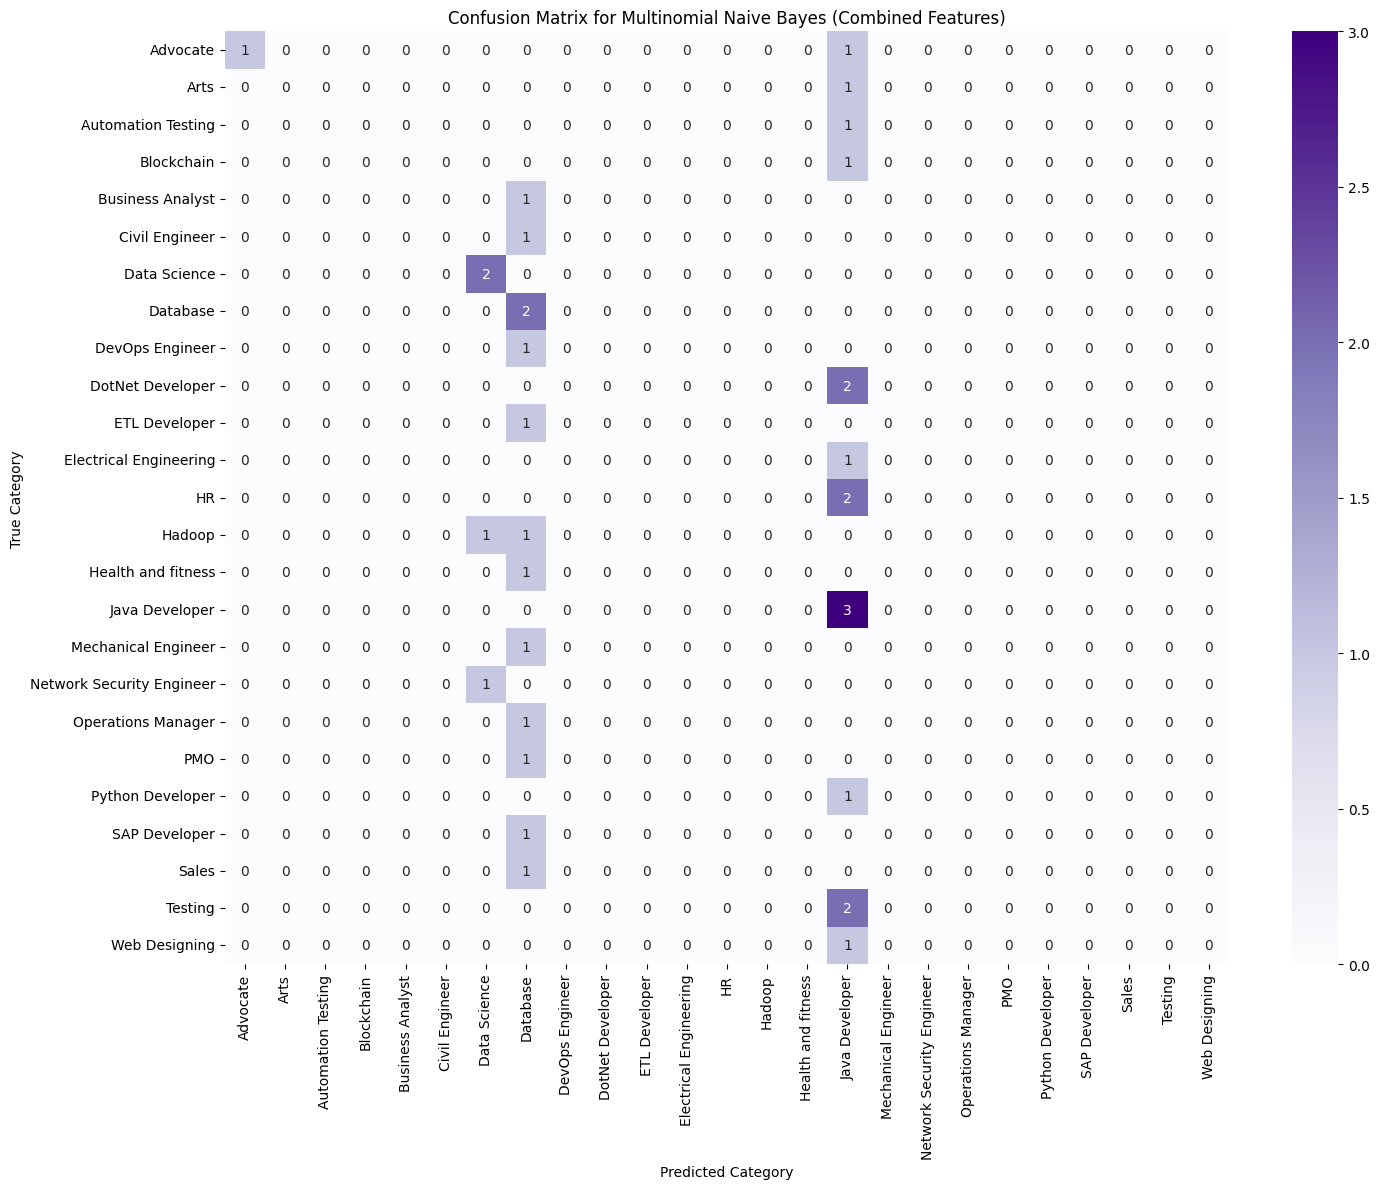

In [65]:
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack # Used for horizontally stacking sparse matrices

# Assuming 'df' DataFrame, 'X_train', 'X_test', 'y_train', 'y_test' are already defined
# and 'cleaned_resume_length' column exists in 'df'.

print("\n--- Integrating 'resume_length' as an Additional Feature ---")

# 1. Extract resume_length for train/test sets
# We need to ensure the lengths correspond to the correct rows in X_train and X_test.
# The simplest way, given X_train and X_test were derived from X (the full TF-IDF matrix),
# is to use the indices from the original train_test_split.

# Get the original indices used for splitting
# This assumes X_train and X_test were created from X directly.
# If you didn't keep track of indices, you'd need to re-split or ensure alignment.
# A more robust way (as mentioned in the prompt) is to include all features in the initial split.

# Let's assume the split was done on df directly for features:
# If you split 'X' (TF-IDF) and 'y' (category_encoded) like this:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Then X_train and X_test are sparse matrices, and we need their original indices to get lengths.

# The most robust way is to split the original DataFrame first and then vectorize.
# Let's re-run the split to ensure feature alignment for demonstration.

# Re-split the data, but this time, keep track of indices or split the dataframe first.
# For simplicity, let's align based on the existing split's indices, which are implicit.
# A better practice would be to split the dataframe and then apply vectorization on subsets.

# Let's assume you stored the original indices from the train_test_split
# If not, you might need to re-run the split ensuring df is split first, then vectorization.
# For demonstration, we'll extract directly from the full df assuming the split order.
# This assumes the original split was truly random and preserves order relative to X.
# In production, splitting the dataframe first is safer.

# For demonstration, let's re-create the train/test splits for all features from the dataframe,
# then apply TF-IDF and scaling.

# Re-splitting df to ensure consistent indices for all features
df_train, df_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42, stratify=y)

# Apply TF-IDF on the cleaned_resume column for the new splits
tfidf_vectorizer_new = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer_new.fit_transform(df_train['cleaned_resume'])
X_test_tfidf = tfidf_vectorizer_new.transform(df_test['cleaned_resume']) # Only transform test data

# 2. Extract and Scale 'resume_length'
scaler = MinMaxScaler()

# Reshape to 2D array for the scaler
train_lengths = df_train['resume_length'].values.reshape(-1, 1)
test_lengths = df_test['resume_length'].values.reshape(-1, 1)

# Fit scaler on training data and transform both train and test data
scaled_train_lengths = scaler.fit_transform(train_lengths)
scaled_test_lengths = scaler.transform(test_lengths)

print(f"\nShape of Scaled Training Lengths: {scaled_train_lengths.shape}")
print(f"Shape of Scaled Testing Lengths: {scaled_test_lengths.shape}")

# 3. Concatenate (Stack) the features
# Use hstack for horizontal stacking of sparse matrix (TF-IDF) with dense array (scaled length)
X_train_combined = hstack([X_train_tfidf, scaled_train_lengths])
X_test_combined = hstack([X_test_tfidf, scaled_test_lengths])

print(f"\n✅ Shape of Combined Training Features: {X_train_combined.shape}")
print(f"✅ Shape of Combined Testing Features: {X_test_combined.shape}")

# Now, train and evaluate the Multinomial Naive Bayes model with the combined features
print("\n--- Training Multinomial Naive Bayes with Combined Features ---")

mnb_classifier_combined = MultinomialNB()
mnb_classifier_combined.fit(X_train_combined, y_train)
y_pred_mnb_combined = mnb_classifier_combined.predict(X_test_combined)

accuracy_combined = accuracy_score(y_test, y_pred_mnb_combined)
print(f"\n✅ Accuracy of Multinomial Naive Bayes with Combined Features: {accuracy_combined:.4f}")

print("\nClassification Report (Multinomial Naive Bayes with Combined Features):")
print(classification_report(y_test, y_pred_mnb_combined, target_names=le.classes_))

# Confusion Matrix for Combined Features Model
cm_combined = confusion_matrix(y_test, y_pred_mnb_combined)

plt.figure(figsize=(15, 12))
sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Multinomial Naive Bayes (Combined Features)')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.tight_layout()
plt.show()

## Confusion Matrix


--- Multinomial Naive Bayes Confusion Matrix ---


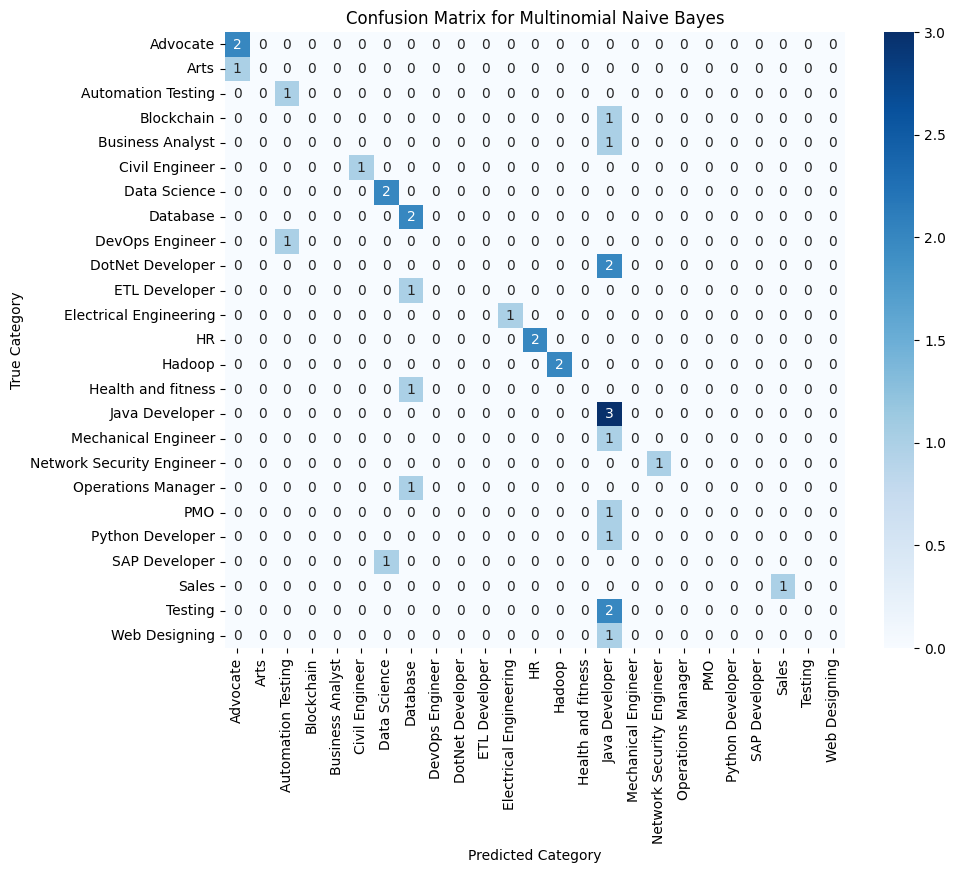

In [66]:
print("\n--- Multinomial Naive Bayes Confusion Matrix ---")
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Multinomial Naive Bayes')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.show()

In [67]:
print(f"\n✅ Accuracy Score (Multinomial Naive Bayes): {accuracy_score(y_test, y_pred_nb):.4f}")



✅ Accuracy Score (Multinomial Naive Bayes): 0.5294


# Random Forest

## Building a histogram by category

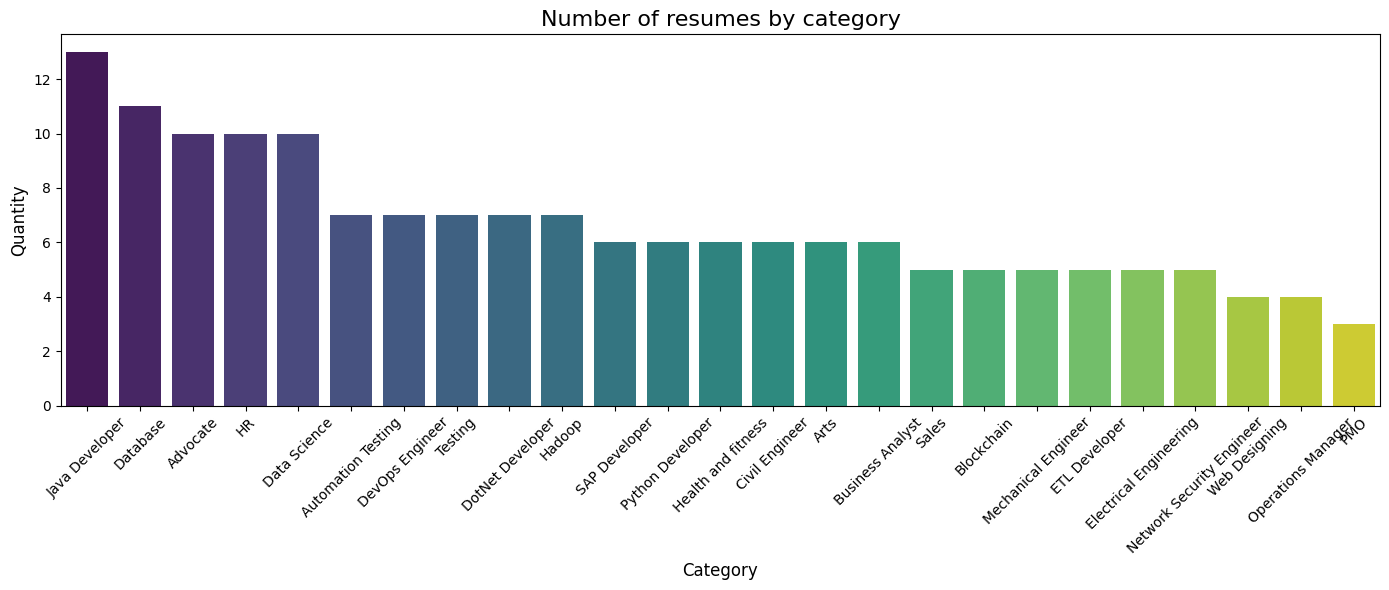

In [68]:
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df,
    x='Category',
    order=df['Category'].value_counts().index,
    palette='viridis'
)
plt.title("Number of resumes by category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Quantity", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

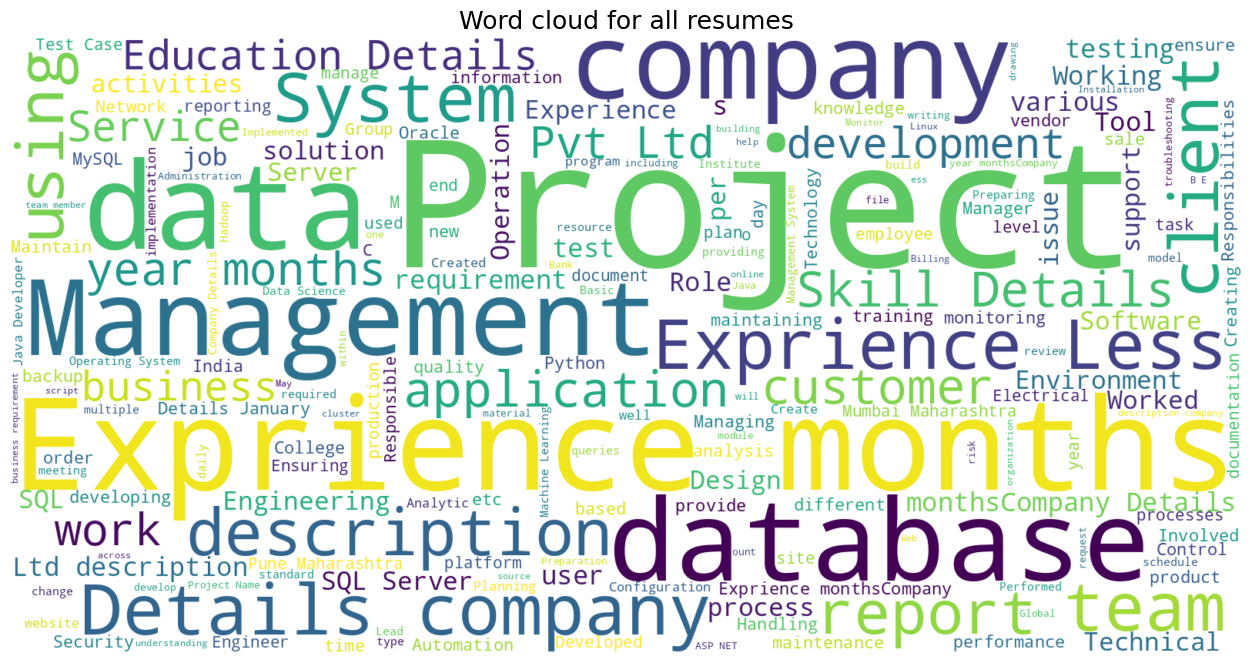

In [69]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_data = " ".join(df['cleaned_resume'])

wordcloud = WordCloud(
    width=1600, 
    height=800, 
    background_color='white', 
    max_words=200, 
    colormap='viridis'
).generate(text_data)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word cloud for all resumes", fontsize=18)
plt.show()

In [70]:
# Now encode the data
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['new_Category'] = label.fit_transform(df['Category'])
df.head()

,Category,Resume,cleaned_resume,Processed_Resume,resume_length,Encoded_Category,new_Category
0,Data Science,Skills Programming Languages Python pandas num...,Skills Programming Languages Python pandas num...,Skills Programming Languages Python pandas num...,653,6,6
1,Data Science,Education Details May 2013 to May 2017 B E UIT...,Education Details May 2013 to May 2017 B E UIT...,Education Details May 2013 to May 2017 B E UIT...,163,6,6
2,Data Science,Areas of Interest Deep Learning Control System...,Areas of Interest Deep Learning Control System...,Areas of Interest Deep Learning Control System...,267,6,6
3,Data Science,Skills R Python SAP HANA Tableau SAP HANA SQL ...,Skills R Python SAP HANA Tableau SAP HANA SQL ...,Skills R Python SAP HANA Tableau SAP HANA SQL ...,944,6,6
4,Data Science,Education Details MCA YMCAUST Faridabad Haryan...,Education Details MCA YMCAUST Faridabad Haryan...,Education Details MCA YMCAUST Faridabad Haryan...,61,6,6


(array([23., 11., 27., 14., 10., 23., 18., 12., 12., 16.]),
 array([ 0. ,  2.4,  4.8,  7.2,  9.6, 12. , 14.4, 16.8, 19.2, 21.6, 24. ]),
 <BarContainer object of 10 artists>)

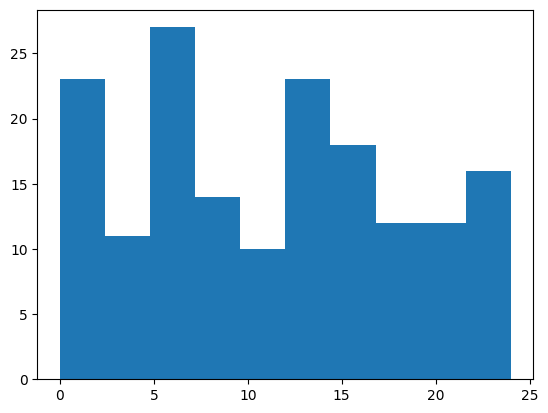

In [71]:
plt.hist(df['new_Category'])

# To learn the top keywords to analyze.

In [72]:
print("✔️Original Category Distribution:")
print(df['Category'].value_counts())

# Find the max number of resumes in any category
max_size = df['Category'].value_counts().max()

# Oversample smaller categories to match max_size
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)

# Shuffle to mix the rows randomly after oversampling
df = balanced_df.sample(frac=1).reset_index(drop=True)

print("\n✔️Balanced Category Distribution (After Oversampling):")
print(df['Category'].value_counts())

✔️Original Category Distribution:
Category
Java Developer               13
Database                     11
Advocate                     10
HR                           10
Data Science                 10
Automation Testing            7
DevOps Engineer               7
Testing                       7
DotNet Developer              7
Hadoop                        7
SAP Developer                 6
Python Developer              6
Health and fitness            6
Civil Engineer                6
Arts                          6
Business Analyst              6
Sales                         5
Blockchain                    5
Mechanical Engineer           5
ETL Developer                 5
Electrical Engineering        5
Network Security Engineer     5
Web Designing                 4
Operations Manager            4
PMO                           3
Name: count, dtype: int64

✔️Balanced Category Distribution (After Oversampling):
Category
Automation Testing           13
Hadoop                       13
ET

In [73]:
from sklearn.preprocessing import LabelEncoder

re = LabelEncoder()

# Learn mapping from text labels to numbers
re.fit(df['Category'])

# Transform categories into numeric labels
df['Category'] = re.transform(df['Category'])

# Check unique numeric labels
print("✔️Unique numeric categories:", df['Category'].unique())

# Optionally, check mapping for reference
print("✔️Category mapping:")
for i, label in enumerate(re.classes_):
    print(f"{label} --> {i}")

✔️Unique numeric categories: [ 2 13 10  7  0  8 20 22  1 16 24 18  5 21  9 15 17 14  6 23 19 11  3 12
  4]
✔️Category mapping:
Advocate --> 0
Arts --> 1
Automation Testing --> 2
Blockchain --> 3
Business Analyst --> 4
Civil Engineer --> 5
Data Science --> 6
Database --> 7
DevOps Engineer --> 8
DotNet Developer --> 9
ETL Developer --> 10
Electrical Engineering --> 11
HR --> 12
Hadoop --> 13
Health and fitness --> 14
Java Developer --> 15
Mechanical Engineer --> 16
Network Security Engineer --> 17
Operations Manager --> 18
PMO --> 19
Python Developer --> 20
SAP Developer --> 21
Sales --> 22
Testing --> 23
Web Designing --> 24


In [74]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer to ignore common English stopwords
tfidf = TfidfVectorizer(stop_words='english')

# Learn vocabulary and idf from resumes
tfidf.fit(df['Resume'])

# Transform all resumes into TF-IDF feature matrix (sparse matrix)
X = tfidf.transform(df['Resume'])
 

print(f"✔️TF-IDF matrix shape: {X.shape}")

✔️TF-IDF matrix shape: (325, 6664)


In [75]:
from sklearn.model_selection import train_test_split

# 'X' is our feature matrix, 'y' are the labels
X_train, X_test, y_train, y_test = train_test_split(
    X,                   # Features (TF-IDF matrix)
    df['Category'],      # Target labels
    test_size=0.2,       # 20% data for testing
    random_state=42      # For reproducibility
)

print(f"✔️Training data shape: {X_train.shape}")
print(f"✔️Testing data shape: {X_test.shape}")

✔️Training data shape: (260, 6664)
✔️Testing data shape: (65, 6664)


>"We keep 80% of data for training and 20% for testing. The random_state ensures the split is the same every time you run this."

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Convert sparse matrices to dense arrays if needed
X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test_dense = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

# Initialize and train the model
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(X_train_dense, y_train)

# Predict on test data
y_pred_knn = knn_model.predict(X_test_dense)

# Evaluate results
print("\n✔️KNeighborsClassifier Results:")
print(f"✔️Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("✔️Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\n✔️Classification Report:")
print(classification_report(y_test, y_pred_knn))


✔️KNeighborsClassifier Results:
✔️Accuracy: 0.7846
✔️Confusion Matrix:
[[3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0

>“KNN works by looking at the ‘neighbors’ of a resume — the most similar ones — to decide the category. The classification report shows precision, recall, and F1-score for each category so we can see how well it’s performing.”

In [77]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train the SVC model
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(X_train_dense, y_train)

# Predict on test data
y_pred_svc = svc_model.predict(X_test_dense)

# Evaluate results
print("\n✔️SVC Results:")
print(f"✔️Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print("✔️Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))
print("\n✔️Classification Report:")
print(classification_report(y_test, y_pred_svc))


✔️SVC Results:
✔️Accuracy: 0.8923
✔️Confusion Matrix:
[[3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 

>“SVM tries to maximize the margin between different categories, making it robust and effective for text classification.”

**Remember that this is a starting point, and further research would involve hyperparameter tuning, trying different models, and more advanced NLP techniques.**